<a href="https://colab.research.google.com/github/7vika-lgtm/breast-research-ml/blob/main/breast_research_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Diagnosis: A Machine Learning Research Project
**Goal:** Predict whether a breast mass is *malignant* or *benign* from cell-nucleus measurements (Wisconsin Diagnostic Breast Cancer dataset).

**Research questions**
1. Which features best separate malignant from benign tumors?
2. Which model performs best, and how reliably?
3. In a medical setting, how do we minimize missed cancers (false negatives)?

*Educational project only, not for clinical use.*

## 1. Setup

In [13]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, precision_recall_curve)
from sklearn.inspection import permutation_importance
sns.set_theme(style="whitegrid")
RS = 42

## 2. Load data

In [14]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
# In sklearn: target 0 = malignant, 1 = benign. Flip so 1 = malignant (the positive class of interest).
df["target"] = 1 - df["target"]
print(df.shape)
print(df["target"].value_counts().rename({0:"benign",1:"malignant"}))
df.head()

(569, 31)
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Exploratory data analysis

In [15]:
print("Missing values:", df.isna().sum().sum())
df.describe().T.head(12)

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


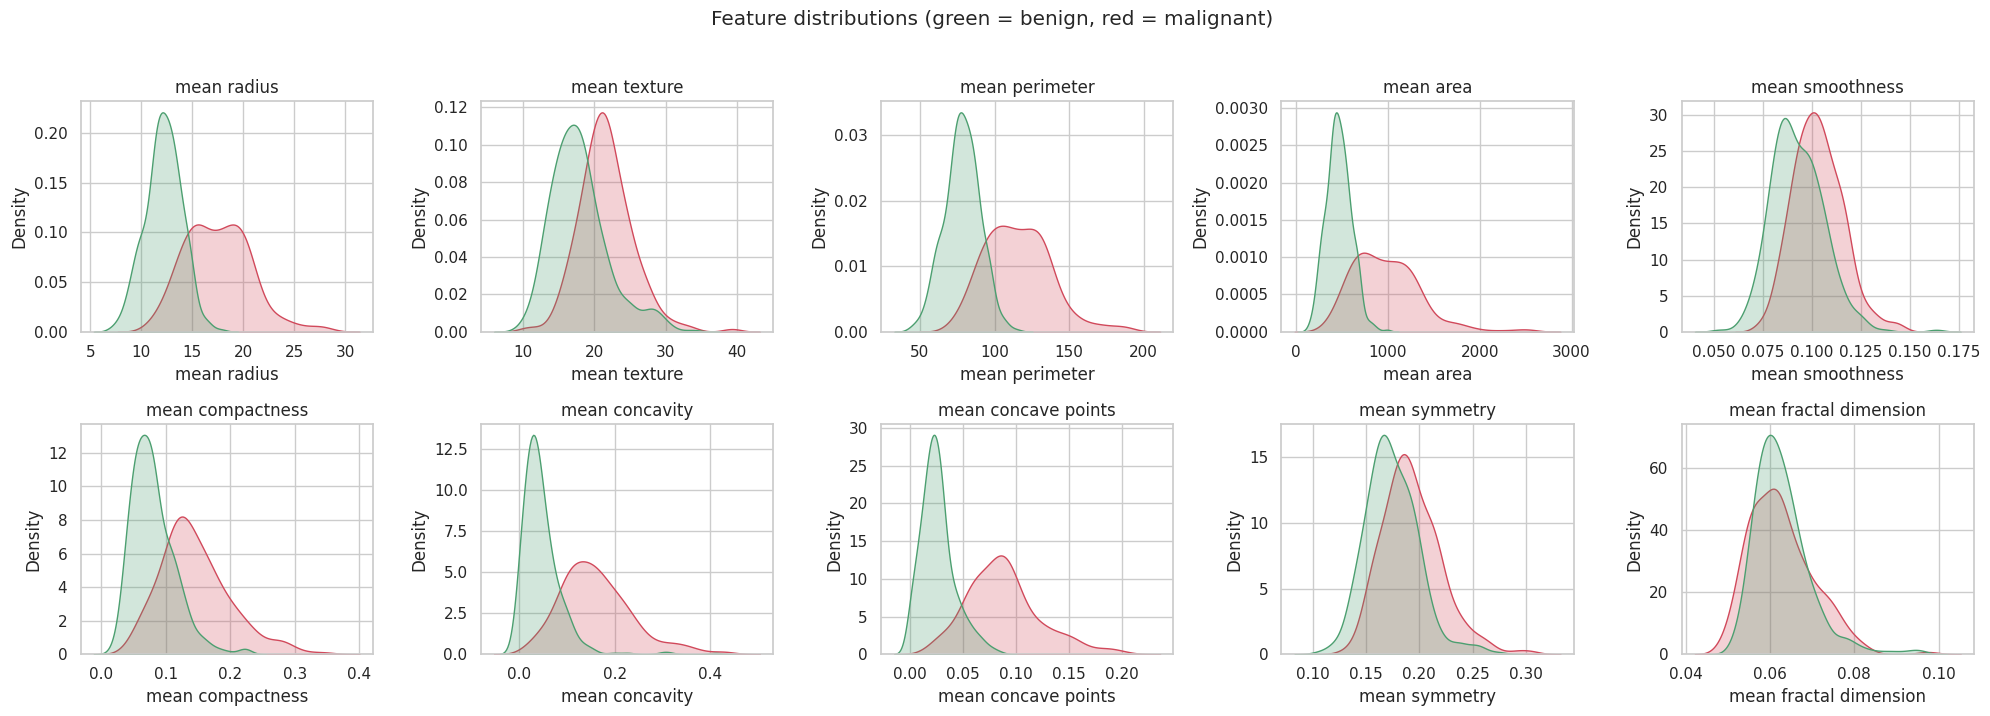

In [16]:
mean_cols = [c for c in df.columns if c.startswith("mean")]
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), mean_cols):
    sns.kdeplot(data=df, x=col, hue="target", fill=True, ax=ax, common_norm=False, palette=["#4C9F70","#D1495B"])
    ax.set_title(col); ax.legend_.remove() if ax.legend_ else None
plt.suptitle("Feature distributions (green = benign, red = malignant)", y=1.02)
plt.tight_layout(); plt.show()

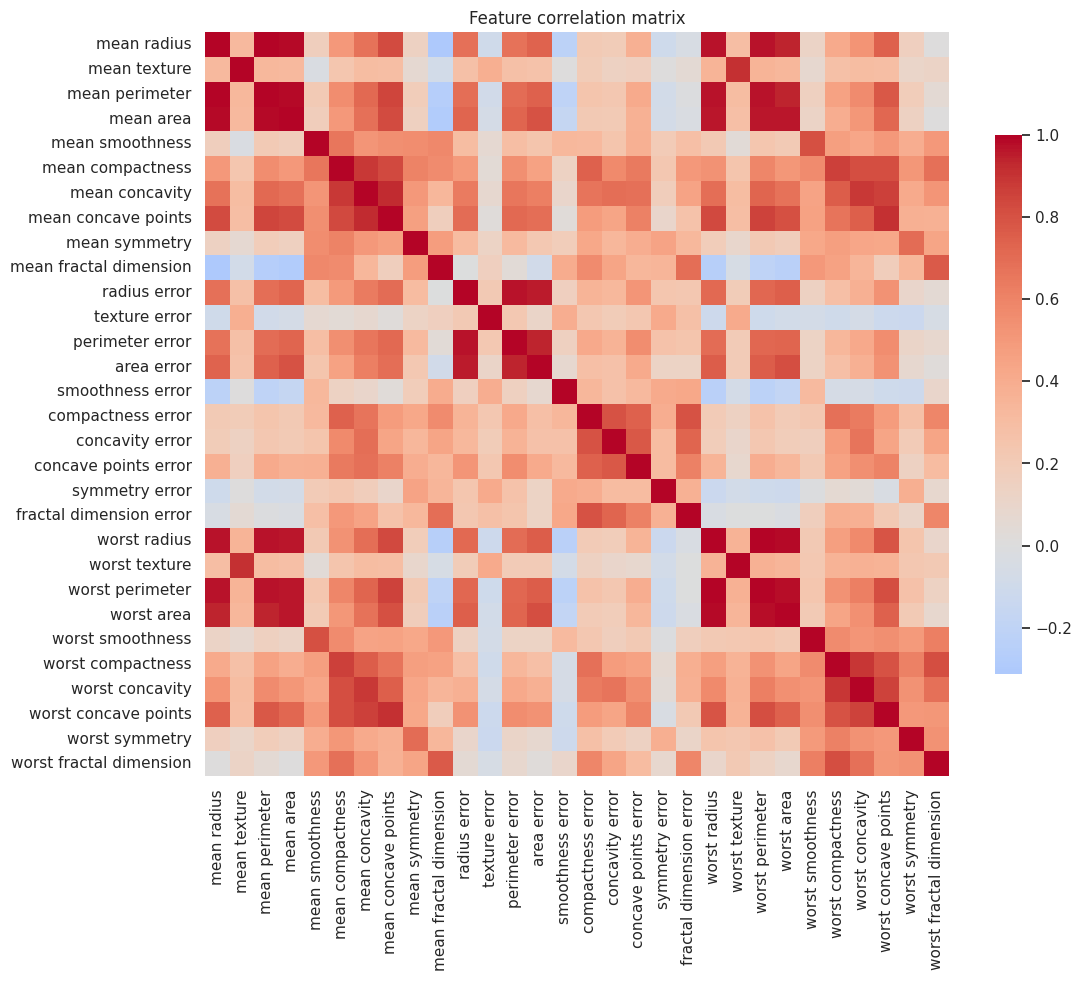

,target
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360
worst concavity,0.659610


In [17]:
corr = df.drop(columns="target").corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink":.7})
plt.title("Feature correlation matrix"); plt.show()

# Strongest correlations with the diagnosis
df.corr()["target"].drop("target").abs().sort_values(ascending=False).head(10)

**Observation:** Size/shape features (radius, perimeter, area, concavity) are strongly tied to malignancy, and many features are highly correlated with each other (multicollinearity), which matters for linear models.

## 4. Train/test split

In [18]:
X = df.drop(columns="target"); y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


## 5. Model comparison (5-fold stratified cross-validation)

In [19]:
models = {
    "Logistic Regression": Pipeline([("sc", StandardScaler()), ("m", LogisticRegression(max_iter=5000))]),
    "SVM (RBF)":           Pipeline([("sc", StandardScaler()), ("m", SVC(probability=True, random_state=RS))]),
    "KNN":                 Pipeline([("sc", StandardScaler()), ("m", KNeighborsClassifier())]),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RS),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RS),
}
cv = StratifiedKFold(5, shuffle=True, random_state=RS)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
rows = []
for name, mdl in models.items():
    r = cross_validate(mdl, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name, **{s: r[f"test_{s}"].mean() for s in scoring}})
results = pd.DataFrame(rows).set_index("model").round(4).sort_values("recall", ascending=False)
results

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.9736,0.9771,0.9529,0.9640,0.9958
SVM (RBF),0.9714,0.9769,0.9471,0.9610,0.9949
Gradient Boosting,0.9670,0.9646,0.9471,0.9553,0.9908
Random Forest,0.9604,0.9584,0.9353,0.9461,0.9880
KNN,0.9648,0.9875,0.9176,0.9510,0.9871


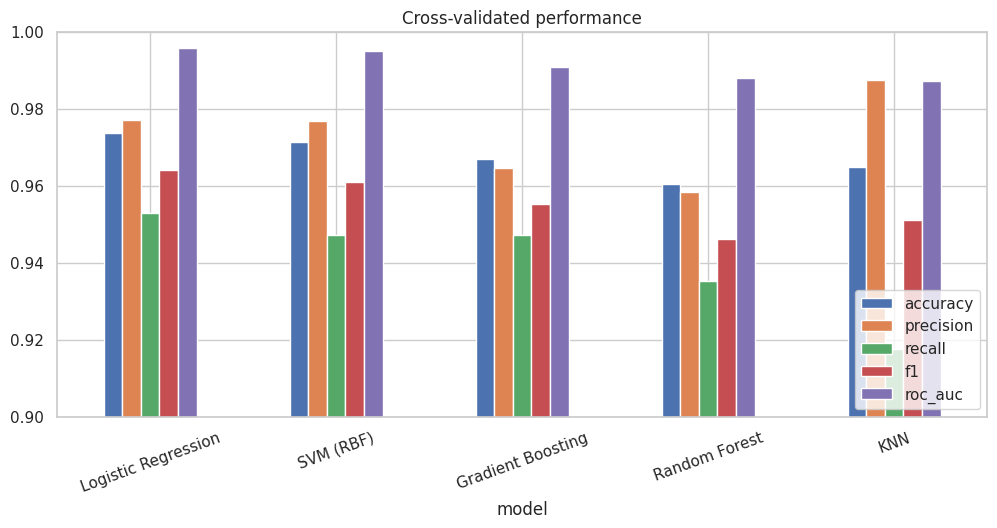

In [20]:
results.plot(kind="bar", figsize=(12, 5), ylim=(0.9, 1.0))
plt.title("Cross-validated performance"); plt.xticks(rotation=20); plt.legend(loc="lower right"); plt.show()

## 6. Hyperparameter tuning (best candidate: SVM)
We optimize **recall** because a missed cancer is far costlier than a false alarm.

In [21]:
param_grid = {"m__C": [0.1, 1, 10, 100], "m__gamma": ["scale", 0.01, 0.001]}
gs = GridSearchCV(models["SVM (RBF)"], param_grid, cv=cv, scoring="recall", n_jobs=-1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_, "| CV recall:", round(gs.best_score_, 4))
best = gs.best_estimator_

Best params: {'m__C': 10, 'm__gamma': 'scale'} | CV recall: 0.9647


## 7. Final evaluation on held-out test set

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC AUC: 0.9927


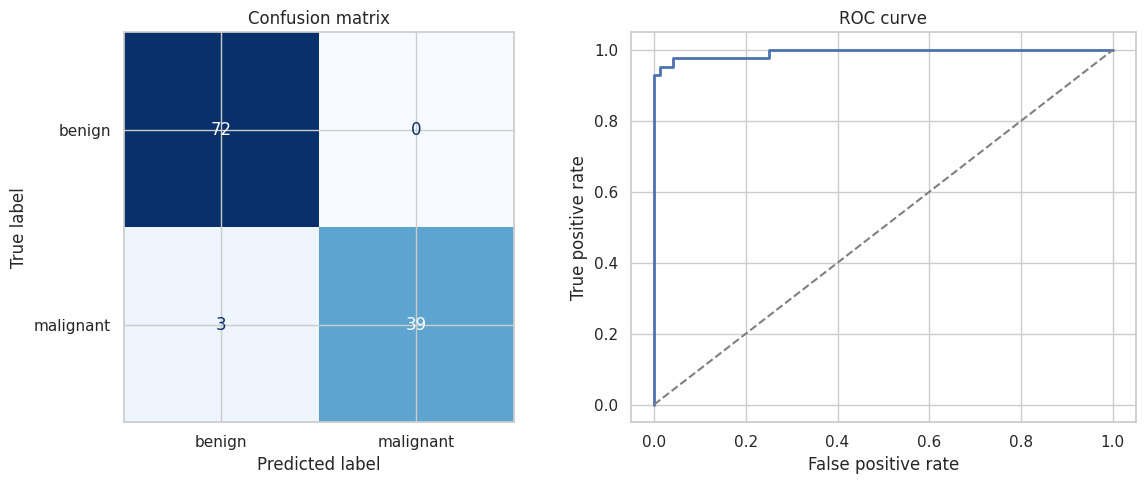

In [22]:
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["benign","malignant"]))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["benign","malignant"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion matrix")
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, lw=2); ax[1].plot([0,1],[0,1],"--", c="gray")
ax[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve")
plt.tight_layout(); plt.show()

## 8. Threshold analysis (reducing missed cancers)

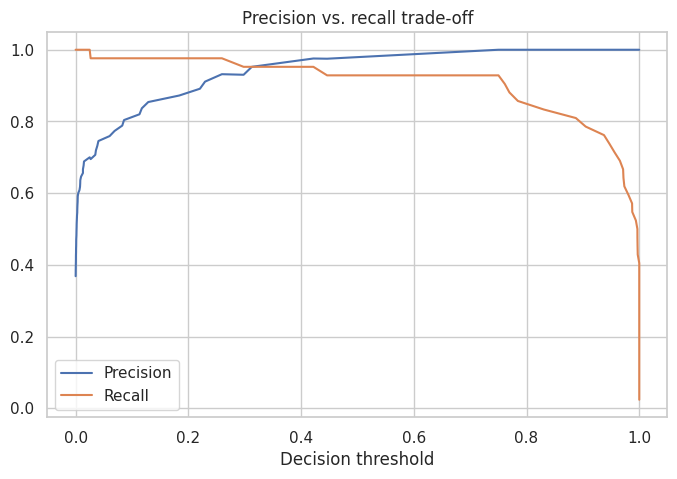

threshold=0.5: missed cancers (FN)=3, false alarms (FP)=0
threshold=0.3: missed cancers (FN)=2, false alarms (FP)=2
threshold=0.2: missed cancers (FN)=1, false alarms (FP)=5


In [23]:
prec, rec, thr = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8,5))
plt.plot(thr, prec[:-1], label="Precision"); plt.plot(thr, rec[:-1], label="Recall")
plt.xlabel("Decision threshold"); plt.legend(); plt.title("Precision vs. recall trade-off"); plt.show()

for t in [0.5, 0.3, 0.2]:
    p = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    print(f"threshold={t}: missed cancers (FN)={fn}, false alarms (FP)={fp}")

## 9. Interpretability: which features matter?

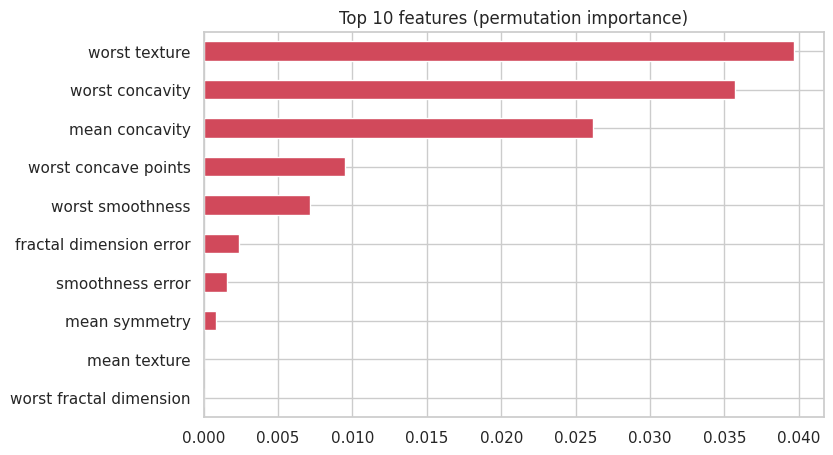

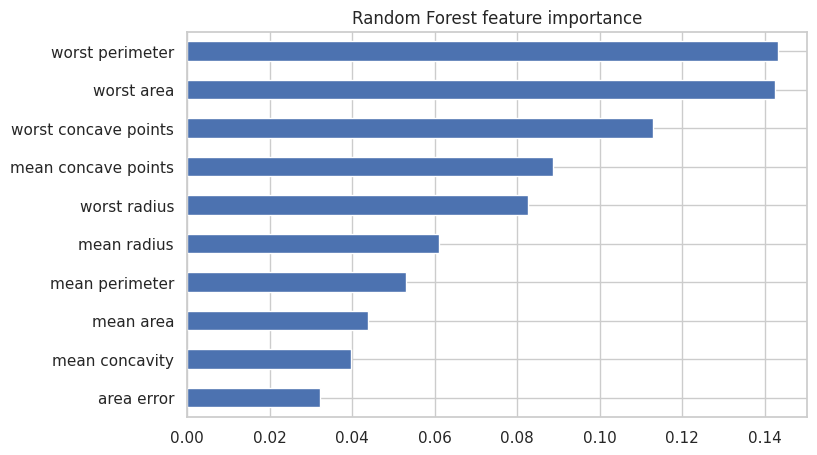

In [24]:
perm = permutation_importance(best, X_test, y_test, scoring="recall", n_repeats=30, random_state=RS)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(10)
imp[::-1].plot(kind="barh", figsize=(8,5), color="#D1495B")
plt.title("Top 10 features (permutation importance)"); plt.show()

rf = RandomForestClassifier(n_estimators=300, random_state=RS).fit(X_train, y_train)
pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10).plot(kind="barh", figsize=(8,5))
plt.title("Random Forest feature importance"); plt.show()

## 10. Conclusions & limitations
- Fill in your own numbers from the results above (best model, recall, AUC, top features).
- **Limitations:** small dataset (569 samples), single institution, features are pre-extracted from images, no external validation.
- **Next steps:** try SHAP explanations, calibrate probabilities, test on another dataset, or train a CNN on histology images (e.g., BreakHis).

## References
- Wolberg, Street & Mangasarian, *Wisconsin Diagnostic Breast Cancer (WDBC)*, UCI ML Repository.
- Scikit-learn documentation: https://scikit-learn.org